In [1]:
from collections import defaultdict

import jax

#jax.config.update("jax_platform_name", "cpu")
import jax.numpy as jnp
import jax.random as jr  
import matplotlib.pyplot as plt
import numpy as np

# Setup

We train MLP in SP and/or μP, and observe the training dynamics wrt the learning rate η for fixed -
 
- batch size $B$ or 
- *temperature* given by $\frac{\eta}{B}$.

We also downscale the last layer by the "richness" parameter γ, which we take to be $.01, .1,  1., 10. 100.$ to observe all regimes.

In [2]:
from batch_size_studies.configs import get_main_experiment_configs, get_main_hyperparameter_grids
from batch_size_studies.data_utils import (
    filter_loss_dicts, moving_average, sample_aware_smooth_loss_dicts, 
    extract_loss_histories, filter_loss_dict_by_cutoff, subsample_loss_dict_periodic,
    filter_experiments
)

from batch_size_studies.definitions import RunKey, LossType, OptimizerType
from batch_size_studies.experiments import (
    Parameterization,
    SyntheticExperimentFixedData,
    SyntheticExperimentFixedTime,
    MNIST1MExperiment,
    MNIST1MSampledExperiment
)
from batch_size_studies.plotting_utils import plot_loss_curves, plot_loss_heatmap,plot_all_loss_curves
from batch_size_studies.runner import run_experiment_sweep



In [3]:
MOVING_AVG_SAMPLES_WINDOW = 1000

rk_smoother = lambda rk, loss_history: moving_average(
    loss_history, 
    max(round(MOVING_AVG_SAMPLES_WINDOW / rk.batch_size), 1)
)

In [4]:
batch_sizes = (2 ** np.arange(0, 10)).tolist()
etas = np.power(2.0, np.linspace(-4, 2, 21)).tolist()


print(f"There are {len(batch_sizes)} batch sizes:")
print(batch_sizes)

print(f"\n There are {len(etas)} learning rates:")
print([f"{eta:.2e}" for eta in etas])

There are 10 batch sizes:
[1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

 There are 21 learning rates:
['6.25e-02', '7.69e-02', '9.47e-02', '1.17e-01', '1.44e-01', '1.77e-01', '2.18e-01', '2.68e-01', '3.30e-01', '4.06e-01', '5.00e-01', '6.16e-01', '7.58e-01', '9.33e-01', '1.15e+00', '1.41e+00', '1.74e+00', '2.14e+00', '2.64e+00', '3.25e+00', '4.00e+00']


In [5]:
all_temps = np.unique(np.array(etas)[:, np.newaxis] / np.array(batch_sizes))
print(f'Temperatures are in the range [2^{round(np.log2(all_temps).min())}, 2^{round(np.log2(all_temps).max())}], logarithmically spaced.')

Temperatures are in the range [2^-13, 2^2], logarithmically spaced.


# Linear Model

In [6]:
from batch_size_studies.experiments import SyntheticExperimentLinearTeacher

In [7]:
experiment = SyntheticExperimentLinearTeacher(
    D = 500,
    P = round(2**14),
    optimizer = OptimizerType.SGD,
    loss_type = LossType.MSE,
    alpha = 1.1,
    beta = 0.1
)

The names of the experiments should follow the convention:

 `<task>_<parameterization>_<loss_fn_type>_<optimizer>_<gamma_value>`


Each experiment object is a Dataclass with all relevant parameters for training dynamics specified. Let's look at one.

In [8]:
from pprint import pprint
import random 
pprint(experiment)

SyntheticExperimentLinearTeacher(D=500,
                                 P=16384,
                                 optimizer=<OptimizerType.SGD: 'SGD'>,
                                 loss_type=<LossType.MSE: 'MSE'>,
                                 alpha=1.1,
                                 beta=0.1,
                                 seed=0,
                                 experiment_type='fixed_data_linear_teacher')


In [9]:
loss_dict, div_runs = run_experiment_sweep(experiment, batch_sizes, etas, no_save=True)

Eta Sweep:   0%|          | 0/21 [00:00<?, ?it/s]

Batch Size Sweep:   0%|          | 0/10 [00:00<?, ?it/s]

The `results_obj` object, loaded from an experiment's results file, is a Python dictionary that maps each hyperparameter trial to its outcome.

*   **Keys**: The keys of the dictionary are `RunKey` objects. A `RunKey` is a lightweight object that uniquely identifies a single training run by its core hyperparameters, which are `batch_size` and `eta` (learning rate).
    *   *Example*: `RunKey(batch_size=64, eta=0.01)`

*   **Values**: The values are dictionaries containing the metrics for that specific run. Common keys in this inner dictionary include:
    *   `'loss_history'`: A list of loss values recorded during training.
    *   `'epoch_test_accuracies'`: A list of test accuracies, one for each epoch.
    *   `'final_test_accuracy'`: The final test accuracy achieved by the run.

In next iteration of the work, we would replace `eta` with object fully specifying the behavior of the appropriate optimizer (say, betas for Adam).

## Online losses in batches and in temp

To treat runs wtih different batch sizes (and hence less iterations) together, we smooth the loss curve in sample space, i.e. the window of the moving average depends on the batch size

In [10]:
from batch_size_studies.data_utils import filter_loss_dict_by_loss_threshold, adjust_run_keys_in_dict

In [11]:
# loss_dict = filter_loss_dict_by_loss_threshold(
#     loss_dict, 100
# )



Note that in our code the loss for a batch $\mathcal{B}$ of size $B$ is computed via
$$ 
L(\mathcal{B}) = 1/B \sum_{i \in \mathcal{B}} l(i)
$$
while the theory assumes $L \approx \frac12 \mathbb{E}[L]$, so to match the theory precisely we must divide $\eta \to \frac{\eta}{2}$


In [12]:
# divide_eta_by_two = lambda rk: RunKey(rk.batch_size, rk.eta/2)
# loss_dict = adjust_run_keys_in_dict(loss_dict, divide_eta_by_two)

In [13]:
from batch_size_studies.plotting_utils import plot_heatmap_with_theory_curve
from batch_size_studies.data_utils import get_first_divergence_eta

In [14]:
first_divergence = get_first_divergence_eta(div_runs)

In [15]:
first_divergence

{2: 0.4061261981781177,
 32: 1.148698354997035,
 1: 0.217637640824031,
 4: 0.7578582832551989,
 8: 0.9330329915368074,
 256: 1.741101126592248,
 512: 2.6390158215457875,
 16: 1.148698354997035,
 64: 1.148698354997035,
 128: 1.4142135623730951}

In [16]:
assert False

AssertionError: 

In [ ]:
lambda_max_val = 1
tr_sigma_val = np.sum(np.arange(1, 501)** -1.1)

In [ ]:
tr_sigma_val

np.float64(5.213393659532414)

In [ ]:
x, y = experiment.generate_data(jr.key(0))

In [ ]:
lower_bound = lambda c, b: 2 / (lambda_max_val * (1+ c/b) + (2-c) * tr_sigma_val / b) 

In [ ]:
l = np.arange(1, 500)** -1.1
tr_sq = np.sum(l**2)
upper_bound = lambda b: np.max(2 / (l * ( 1+ 1/b) + tr_sq/(l *b)))
naive_upper_bound = lambda b: np.max(2 / (1 + tr_sq/b))

In [ ]:
2/tr_sq

np.float64(1.3422262272206658)

In [ ]:
etas

[0.0625,
 0.07694652583405726,
 0.09473228540689989,
 0.11662912394210093,
 0.1435872943746294,
 0.1767766952966369,
 0.217637640824031,
 0.2679433656340733,
 0.32987697769322355,
 0.4061261981781177,
 0.5,
 0.615572206672458,
 0.7578582832551989,
 0.9330329915368074,
 1.148698354997035,
 1.4142135623730951,
 1.741101126592248,
 2.143546925072586,
 2.6390158215457875,
 3.2490095854249423,
 4.0]

In [ ]:
c = 1
modified_lower_bound = lambda b: lower_bound(c, b)

In [ ]:
etas

[0.0625,
 0.07694652583405726,
 0.09473228540689989,
 0.11662912394210093,
 0.1435872943746294,
 0.1767766952966369,
 0.217637640824031,
 0.2679433656340733,
 0.32987697769322355,
 0.4061261981781177,
 0.5,
 0.615572206672458,
 0.7578582832551989,
 0.9330329915368074,
 1.148698354997035,
 1.4142135623730951,
 1.741101126592248,
 2.143546925072586,
 2.6390158215457875,
 3.2490095854249423,
 4.0]

In [ ]:
first_divergence

{2: 0.4061261981781177,
 32: 1.148698354997035,
 1: 0.217637640824031,
 4: 0.7578582832551989,
 8: 0.9330329915368074,
 256: 1.741101126592248,
 512: 2.6390158215457875,
 16: 1.148698354997035,
 64: 1.148698354997035,
 128: 1.4142135623730951}

In [ ]:
upper_bound = lambda b: np.max(2 / (l * ( 1+ 1/b) + tr_sq/(l *b)))

In [ ]:
upper_bound_2 = lambda b: 2 * b / tr_sigma_val

In [ ]:
batch_crit = tr_sigma_val /(lambda_max_val * ( 1 - tr_sq / (tr_sigma_val ** 2)))

In [ ]:
batch_crit

np.float64(5.515785895324219)

In [ ]:
x.shape

(16384, 500)

In [ ]:
sigma_hat = 1/x.shape[0] * (x @ x.T)

In [ ]:
# est_max_eigenvalue = jnp.linalg.eig(sigma_hat)
# est_max_eigenvalue

In [ ]:
trace_upper_bound = lambda b: 2 * b /tr_sigma_val

In [ ]:
sample_aware_smooth_loss_dicts(loss_dict, rk_smoother)

{RunKey(batch_size=1, eta=0.08838834764831845): array([2.07142819e+00, 2.07883817e+00, 2.08929785e+00, ...,
        2.17568779e+03, 2.17550280e+03, 2.17618258e+03], shape=(15385,)),
 RunKey(batch_size=1, eta=0.0717936471873147): array([8.69678751e-01, 8.72742630e-01, 8.72669311e-01, ...,
        1.49215408e-04, 1.47965723e-04, 1.47420415e-04], shape=(15385,)),
 RunKey(batch_size=1, eta=0.05831456197105046): array([6.49497833e-01, 6.52561043e-01, 6.50980163e-01, ...,
        6.11539929e-05, 6.08586616e-05, 6.09534627e-05], shape=(15385,)),
 RunKey(batch_size=1, eta=0.047366142703449944): array([5.81009316e-01, 5.84058032e-01, 5.81071858e-01, ...,
        1.30720394e-04, 1.30623145e-04, 1.30721656e-04], shape=(15385,)),
 RunKey(batch_size=1, eta=0.03847326291702863): array([5.63668243e-01, 5.66566103e-01, 5.63001717e-01, ...,
        3.41792675e-04, 3.41991116e-04, 3.42309016e-04], shape=(15385,)),
 RunKey(batch_size=1, eta=0.03125): array([0.57095653, 0.57366842, 0.57016372, ..., 0.0008

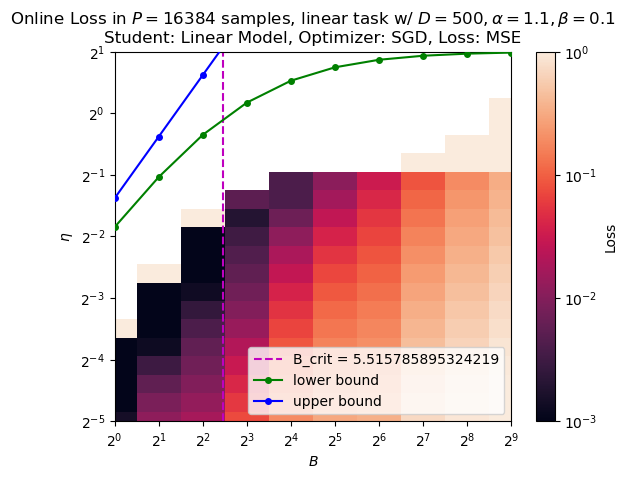

In [ ]:
plot_heatmap_with_theory_curve(
        #sample_aware_smooth_loss_dicts(loss_dict, rk_smoother),
        loss_dict,
        batch_sizes, [e/2 for e in etas], experiment.plot_title(),
        #first_divergence=first_divergence,
        lower_bound=modified_lower_bound,
        upper_bound=trace_upper_bound,
        crit_batch=batch_crit,
        clim=(-3,0)
);

In [ ]:
etas

[0.0625,
 0.07694652583405726,
 0.09473228540689989,
 0.11662912394210093,
 0.1435872943746294,
 0.1767766952966369,
 0.217637640824031,
 0.2679433656340733,
 0.32987697769322355,
 0.4061261981781177,
 0.5,
 0.615572206672458,
 0.7578582832551989,
 0.9330329915368074,
 1.148698354997035,
 1.4142135623730951,
 1.741101126592248,
 2.143546925072586,
 2.6390158215457875,
 3.2490095854249423,
 4.0]

TypeError: object of type 'numpy.float64' has no len()

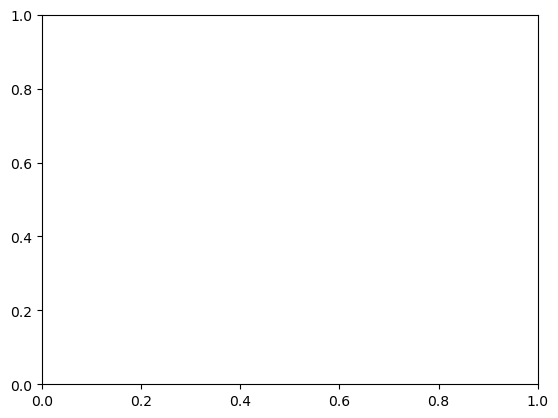

In [ ]:

# Overlays old plot wihth 2/(lamba_max * (1 + 1/b) + Tr(Sigma)/b)
plot_heatmap_with_theory_curve(
    lambda_max_val,
    np.sum(np.arange(1, 500)** -1.1),
    sample_aware_smooth_loss_dicts(loss_dict, rk_smoother),
    batch_sizes,
    etas,
    experiment.plot_title(),
    clim=(-1, 1)
);


To do the heatmap with temperature, i.e. $\frac{\eta}{B}$, as $x$-axis, set the flag `use_ratio_axis` to `True`.

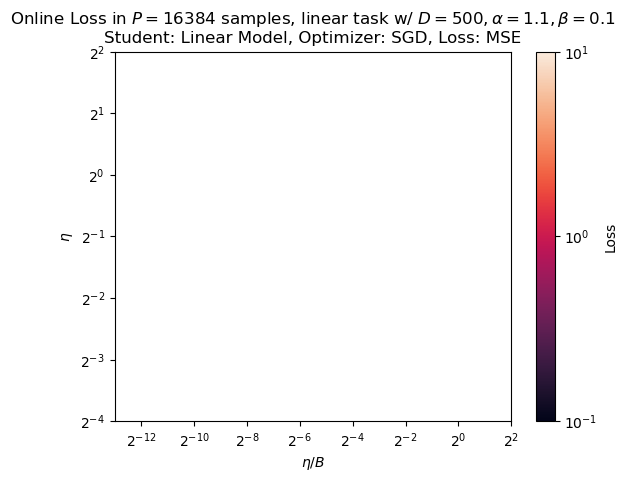

In [ ]:

plot_loss_heatmap(
    sample_aware_smooth_loss_dicts(loss_dict, rk_smoother),
    batch_sizes, etas, experiment.plot_title(), clim=(-1,1),use_ratio_axis = True);

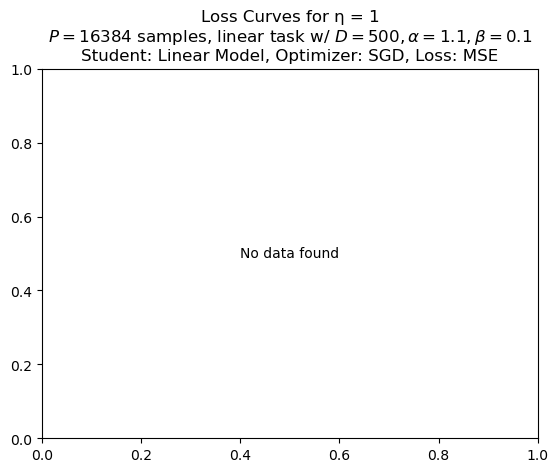

In [ ]:
plot_loss_curves( 
    loss_dict,
    title_exp=experiment.plot_title(),
    group_by="eta",
    group_values=1.0,
    use_samples_seen=True,
    x_scale="log",
    cmap="viridis",
    display_now=True,
)

(<Figure size 2170x800 with 1 Axes>,
 <Axes: title={'center': 'Loss Curves\n$P = 16384$ samples, linear task w/ $D=500, \\alpha=1.1, \\beta=0.1$\nStudent: Linear Model, Optimizer: SGD, Loss: MSE'}, xlabel='Effective Steps (steps * η)', ylabel='Loss'>)

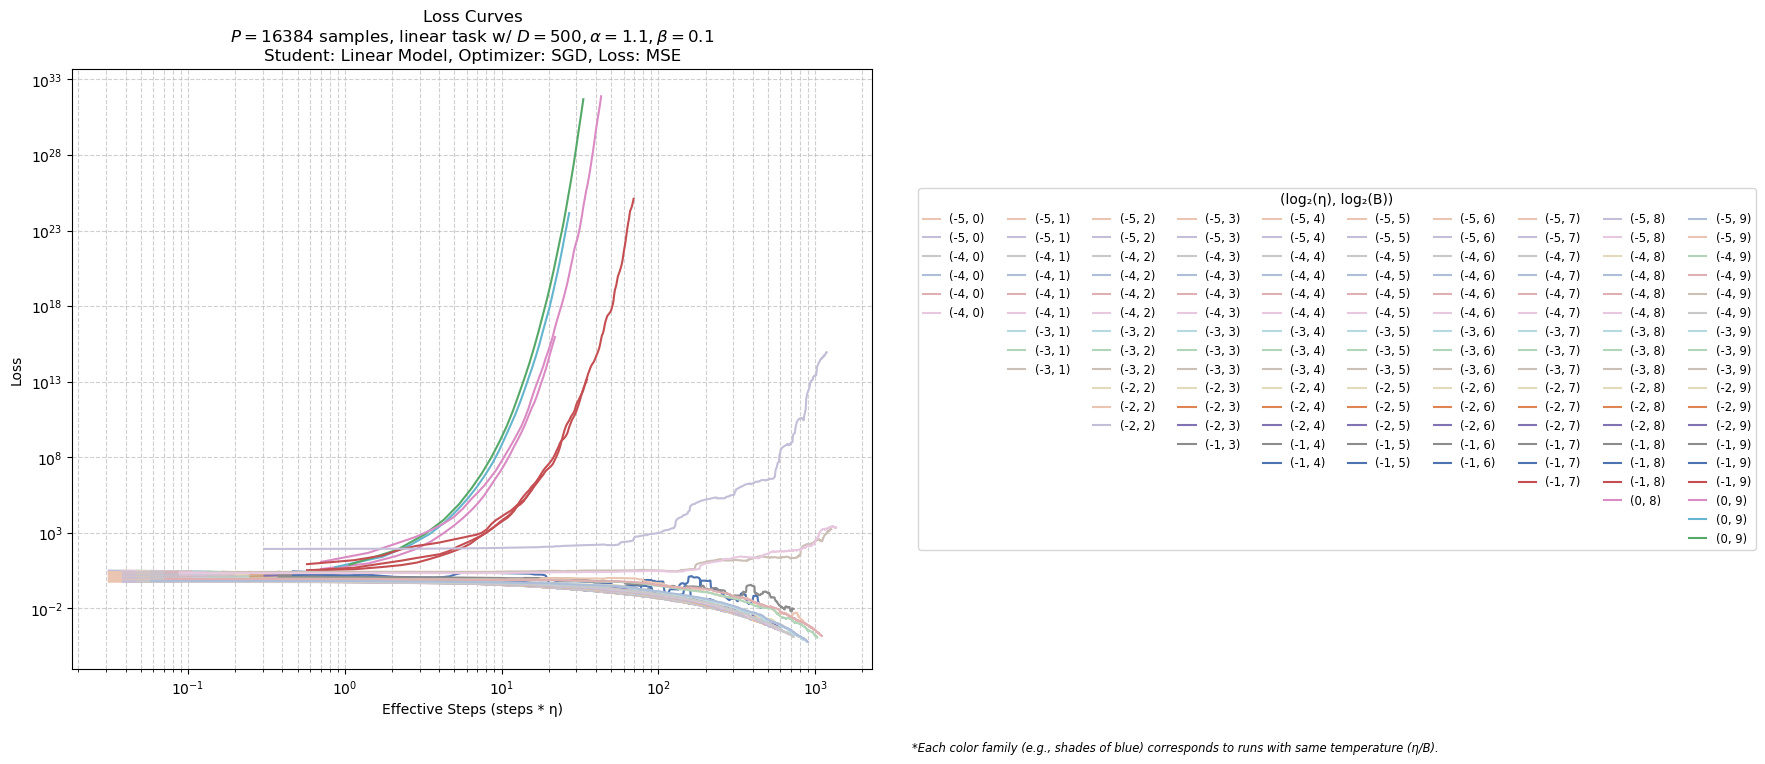

In [ ]:
plot_all_loss_curves(
    sample_aware_smooth_loss_dicts(loss_dict, rk_smoother),
    title_exp=experiment.plot_title(),
    use_eff_steps=True,
    x_scale="log",
)